<a href="https://colab.research.google.com/github/Aakanksha-ML/Project-Valuation-Analysis---UNIFIED-MENTOR-/blob/main/Project_Valuation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns


import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use('fast')

from scipy import stats

%matplotlib inline
# import tensorflow as tf
# from keras.layers import Dense, Dropout, BatchNormalization, Activation
# from keras.optimizers import Adam
# from keras.callbacks import EarlyStopping
# from keras.regularizers import l1, l2
# from keras.models import Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Input data running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/Users/aakankshachaudhary/Downloads/Training and Testing Sets-2'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# import warnings
# warnings.filterwarnings("ignore")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
df=pd.read_csv("unicorns till sep 2022.csv")

In [ ]:
df.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Company         1186 non-null   str  
 1   Valuation ($B)  1186 non-null   str  
 2   Date Joined     1186 non-null   str  
 3   Country         1186 non-null   str  
 4   City            1186 non-null   str  
 5   Industry        1186 non-null   str  
 6   Investors       1168 non-null   str  
dtypes: str(7)
memory usage: 192.0 KB


In [ ]:
df.describe(include='all')

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
count,1186,1186,1186,1186,1186,1186,1168
unique,1183,222,695,48,286,34,1152
top,Bolt,$1,7/13/2021,United States,San Francisco,Fintech,Sequoia Capital
freq,2,271,9,636,168,239,3


In [ ]:
df.isnull().sum()

Company            0
Valuation ($B)     0
Date Joined        0
Country            0
City               0
Industry           0
Investors         18
dtype: int64

In [ ]:
df.dropna(subset=['Investors'],inplace=True)

In [ ]:
df.isnull().sum()

Company           0
Valuation ($B)    0
Date Joined       0
Country           0
City              0
Industry          0
Investors         0
dtype: int64

In [ ]:
df['Valuation ($B)']=df['Valuation ($B)'].str.replace('$','').astype(float)

In [ ]:
df.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,140.0,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,127.0,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,100.0,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,95.0,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,40.0,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."


In [ ]:
df['Date Joined'] = pd.to_datetime(df['Date Joined'], errors='coerce').dt.date


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 1168 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company         1168 non-null   str    
 1   Valuation ($B)  1168 non-null   float64
 2   Date Joined     1168 non-null   object 
 3   Country         1168 non-null   str    
 4   City            1168 non-null   str    
 5   Industry        1168 non-null   str    
 6   Investors       1168 non-null   str    
dtypes: float64(1), object(1), str(5)
memory usage: 184.3+ KB


In [ ]:
# from xml.etree.ElementInclude import include


categorical_columns=df.select_dtypes(include=['str','object'])
categorical_columns

,Company,Date Joined,Country,City,Industry,Investors
0,ByteDance,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,2018-07-03,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
...,...,...,...,...,...,...
1181,LeadSquared,2022-06-21,India,Bengaluru,Internet software & services,"Gaja Capital Partners, Stakeboat Capital, West..."
1182,FourKites,2022-06-21,United States,Chicago,"Supply chain, logistics, & delivery","Hyde Park Venture Partners, Bain Capital Ventu..."
1183,VulcanForms,2022-07-05,United States,Burlington,"Supply chain, logistics, & delivery","Eclipse Ventures, D1 Capital Partners, Industr..."
1184,SingleStore,2022-07-12,United States,San Francisco,Data management & analytics,"Google Ventures, Accel, Data Collective"


In [ ]:
#Label encoding
for col in categorical_columns:
    le = LabelEncoder()
    df[col+'_encoded'] = le.fit_transform(df[col])


In [ ]:
df

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors,Company_encoded,Date Joined_encoded,Country_encoded,City _encoded,Industry_encoded,Investors_encoded
0,ByteDance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",141,77,8,15,1,886
1,SpaceX,127.0,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",915,5,44,104,14,376
2,SHEIN,100.0,2018-07-03,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China...",847,149,8,235,6,1051
3,Stripe,95.0,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",935,10,44,217,8,617
4,Canva,40.0,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",156,114,1,244,12,870
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1181,LeadSquared,1.0,2022-06-21,India,Bengaluru,Internet software & services,"Gaja Capital Partners, Stakeboat Capital, West...",561,676,19,19,12,401
1182,FourKites,1.0,2022-06-21,United States,Chicago,"Supply chain, logistics, & delivery","Hyde Park Venture Partners, Bain Capital Ventu...",366,676,44,55,15,496
1183,VulcanForms,1.0,2022-07-05,United States,Burlington,"Supply chain, logistics, & delivery","Eclipse Ventures, D1 Capital Partners, Industr...",1059,679,44,38,15,333
1184,SingleStore,1.0,2022-07-12,United States,San Francisco,Data management & analytics,"Google Ventures, Accel, Data Collective",888,680,44,217,5,454


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 1168 entries, 0 to 1185
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1168 non-null   str    
 1   Valuation ($B)       1168 non-null   float64
 2   Date Joined          1168 non-null   object 
 3   Country              1168 non-null   str    
 4   City                 1168 non-null   str    
 5   Industry             1168 non-null   str    
 6   Investors            1168 non-null   str    
 7   Company_encoded      1168 non-null   int64  
 8   Date Joined_encoded  1168 non-null   int64  
 9   Country_encoded      1168 non-null   int64  
 10  City _encoded        1168 non-null   int64  
 11  Industry_encoded     1168 non-null   int64  
 12  Investors_encoded    1168 non-null   int64  
dtypes: float64(1), int64(6), object(1), str(5)
memory usage: 239.1+ KB


In [ ]:
X=df.select_dtypes(include=['int64','float64']).drop(['Valuation ($B)'],axis=1)
y=df['Valuation ($B)']

In [ ]:
X

,Company_encoded,Date Joined_encoded,Country_encoded,City _encoded,Industry_encoded,Investors_encoded
0,141,77,8,15,1,886
1,915,5,44,104,14,376
2,847,149,8,235,6,1051
3,935,10,44,217,8,617
4,156,114,1,244,12,870
...,...,...,...,...,...,...
1181,561,676,19,19,12,401
1182,366,676,44,55,15,496
1183,1059,679,44,38,15,333
1184,888,680,44,217,5,454


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
Scaler=StandardScaler()
X_train_scaled=Scaler.fit_transform(X_train)
X_test_scaled=Scaler.transform(X_test)

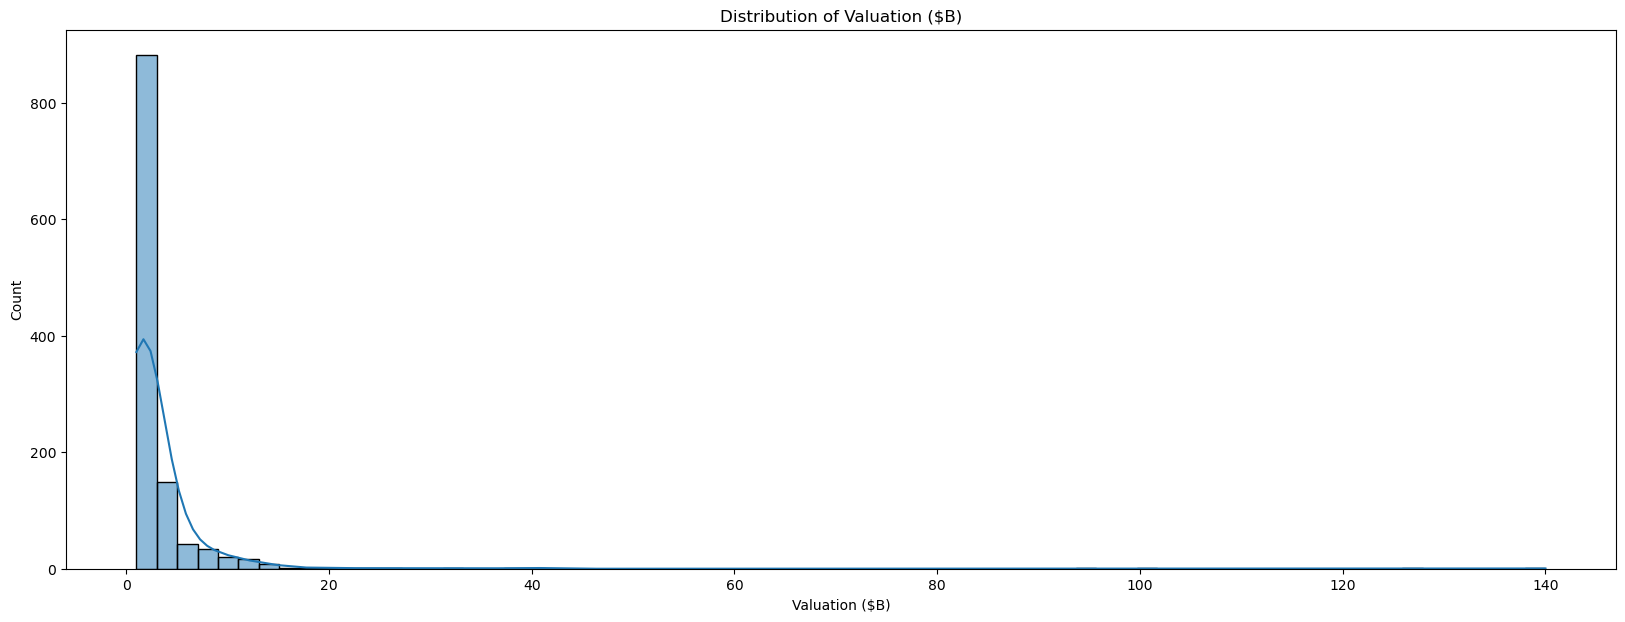

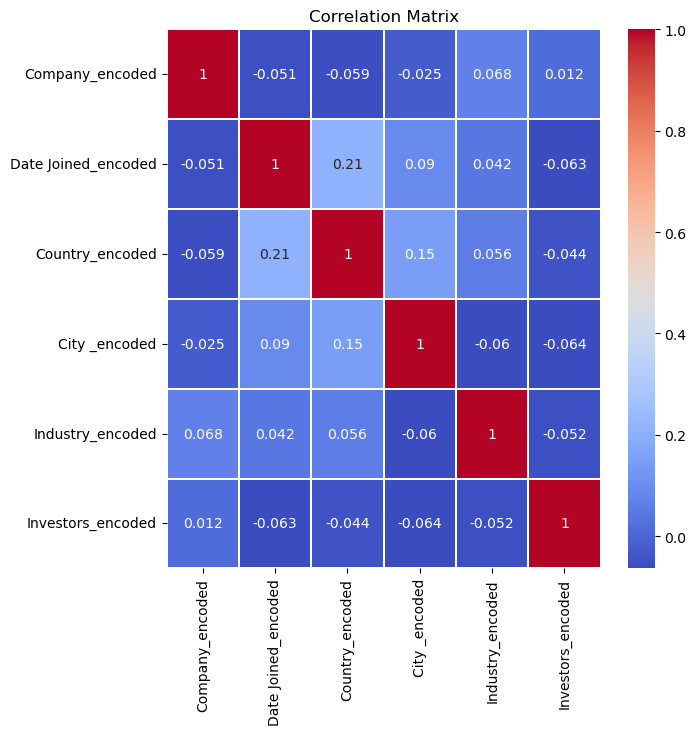

In [ ]:
plt.figure(figsize=(20,7))
sns.histplot(y,kde=True)
plt.title('Distribution of Valuation ($B)')
plt.show()

plt.figure(figsize=(7,7))
sns.heatmap(X.corr(),annot=True,cmap='coolwarm',linewidth=0.1)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
y_pred_lr=lr_model.predict(X_test)

rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)



In [ ]:
#evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mse_lr=mean_squared_error(y_test,y_pred_lr)
r2_lr=r2_score(y_test,y_pred_lr)
print(f'Linear Regression - MSE: {mse_lr}')
print(f'Linear Regression R-squared: {r2_lr}')

mse_rf=mean_squared_error(y_test,y_pred_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print(f'Random Forest - MSE: {mse_rf}')
print(f'Random Forest R-squared: {r2_rf}')


Linear Regression - MSE: 9.512527665116817
Linear Regression R-squared: -0.21652717822088063
Random Forest - MSE: 13.773014036623929
Random Forest R-squared: -0.7613873506001443


In [ ]:
#model tuning and optimization
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search=GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=10, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')




Fitting 10 folds for each of 81 candidates, totalling 810 fits


[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estim

In [ ]:
best_rf_model=grid_search.best_estimator_
best_rf_model.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [ ]:
y_pred_best_rf=best_rf_model.predict(X_test)


In [ ]:
mse_rf_optimized=mean_squared_error(y_test,y_pred_best_rf)
r2_rf_optimized=r2_score(y_test,y_pred_best_rf)
print(f'Optimized Random Forest Mean Squared error: {mse_rf_optimized}')
print(f'Optimized Random Forest R-squared: {r2_rf_optimized}')


Optimized Random Forest Mean Squared error: 11.675806660701562
Optimized Random Forest R-squared: -0.4931821099961453


VALIDATION CURVE FOR REGRESSOR


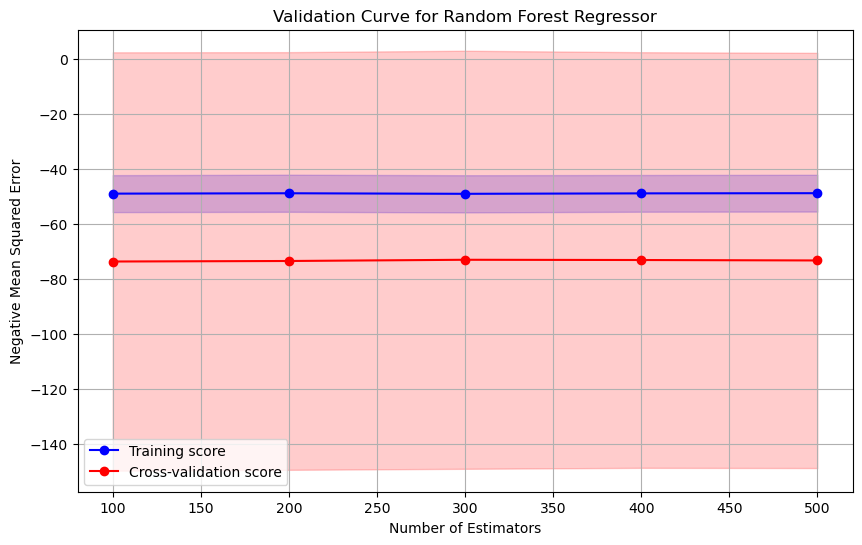

In [ ]:
from sklearn.model_selection import validation_curve
print("="*80)
print("VALIDATION CURVE FOR REGRESSOR")
print('='*80)
#1. Validation curve for Random Forest Regressor
param_range = [100, 200, 300, 400, 500]
train_scores, test_scores = validation_curve(
    best_rf_model, X_train, y_train, param_name='n_estimators', param_range=param_range, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
#Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
# Plot validation curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve for Random Forest Regressor")
plt.xlabel("Number of Estimators")
plt.ylabel("Negative Mean Squared Error")
plt.plot(param_range, train_scores_mean, label="Training score", color="blue", marker='o')
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="blue")
plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="red", marker='o')
plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="red")
plt.legend(loc="best")
plt.grid()
plt.show()


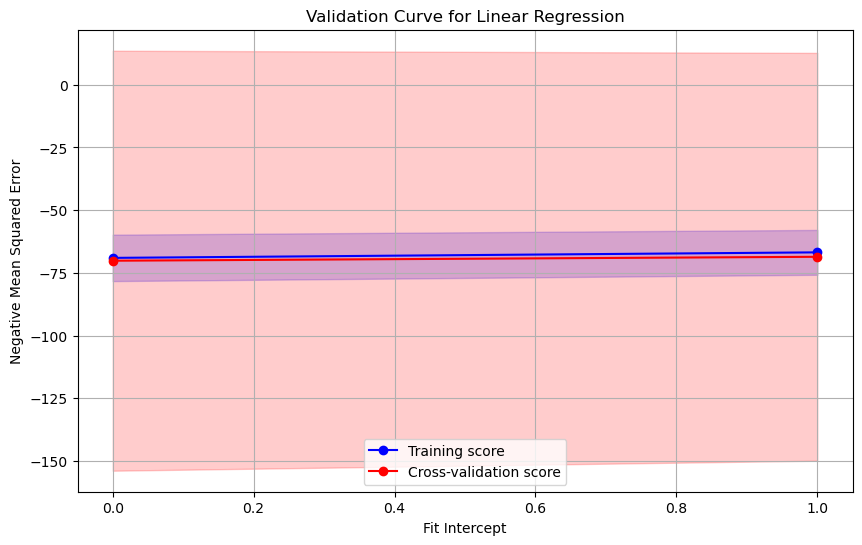

In [ ]:
#validation curve for linear regression
param_range = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
train_scores, test_scores = validation_curve(
    lr_model, X_train, y_train, param_name='fit_intercept', param_range=[True, False], cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
#Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
# Plot validation curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve for Linear Regression")
plt.xlabel("Fit Intercept")
plt.ylabel("Negative Mean Squared Error")
plt.plot([True, False], train_scores_mean, label="Training score", color="blue", marker='o')
plt.fill_between([True, False], train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="blue")
plt.plot([True, False], test_scores_mean, label="Cross-validation score", color="red", marker='o')
plt.fill_between([True, False], test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="red")
plt.legend(loc="best")
plt.grid()
plt.show()

# Task
Generate a comprehensive report summarizing the data analysis and model building process, including: a summary of data loading and initial exploration (dataset shape, columns, initial observations from `df.head()` and `df.info()`); a summary of data preprocessing steps (handling missing values, converting 'Valuation ($B)' and 'Date Joined' columns, applying Label Encoding); a summary of exploratory data analysis (distribution of 'Valuation ($B)' and correlation matrix); a summary of initial model training and evaluation (MSE and R-squared for Linear Regression and Random Forest); a summary of model optimization (GridSearchCV best parameters and best score for Random Forest); a summary of optimized model performance (MSE and R-squared for optimized Random Forest); and a summary of insights from validation curve analysis for both Random Forest Regressor and Linear Regression.

## Summarize Data Loading and Initial Exploration

### Subtask:
Provide a summary of the dataset, including its shape, columns, and initial observations (e.g., from df.head() and df.info()).


**Reasoning**:
The user requested to print the shape of the DataFrame `df`.



In [1]:
print(f"DataFrame shape: {df.shape}")

NameError: name 'df' is not defined

**Reasoning**:
The previous code failed because the DataFrame `df` was not defined in the current execution context. This step ensures `df` is loaded from the CSV file into its initial state and then performs the requested operations to summarize its shape, columns, and provide initial observations using `df.head()` and `df.info()` for the 'Summarize Data Loading and Initial Exploration' subtask, as per the instructions.



In [2]:
import pandas as pd

df = pd.read_csv("unicorns till sep 2022.csv")

print(f"DataFrame shape: {df.shape}")
print(f"DataFrame columns: {df.columns.tolist()}")
print("\nFirst 5 rows of the DataFrame:")
display(df.head())
print("\nConcise summary of the DataFrame:")
df.info()

DataFrame shape: (1186, 7)
DataFrame columns: ['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City\xa0', 'Industry', 'Investors']

First 5 rows of the DataFrame:


,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."



Concise summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Company         1186 non-null   object
 1   Valuation ($B)  1186 non-null   object
 2   Date Joined     1186 non-null   object
 3   Country         1186 non-null   object
 4   City            1186 non-null   object
 5   Industry        1186 non-null   object
 6   Investors       1168 non-null   object
dtypes: object(7)
memory usage: 65.0+ KB


The dataset, named `unicorns till sep 2022.csv`, contains information about unicorn companies. It has a shape of (1186, 7), meaning it comprises 1186 rows (entries) and 7 columns. The columns are 'Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City ', 'Industry', and 'Investors'.

Initial observations from `df.head()` show that all columns are currently of `object` dtype (likely strings), even 'Valuation ($B)' which contains a '$' prefix, and 'Date Joined' which is in a string date format. The `df.info()` output confirms these data types and also indicates that the 'Investors' column has 18 missing values out of 1186 entries (1168 non-null), while all other columns ('Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City ', 'Industry') are complete with 1186 non-null entries. The 'City ' column name contains a non-standard character (\xa0, a non-breaking space), which might require cleaning during preprocessing.

## Summarize Data Preprocessing

### Subtask:
Detail the steps taken for data cleaning and preprocessing, such as handling missing values, converting 'Valuation ($B)' and 'Date Joined' columns, and applying Label Encoding to categorical features.


### Data Preprocessing Summary

1.  **Handling Missing Values**: Missing values in the 'Investors' column were addressed by dropping the rows containing these null entries. This resulted in a reduction of the dataset from 1186 to 1168 rows.
2.  **Converting 'Valuation ($B)' Column**: The 'Valuation ($B)' column, initially stored as a string with a '$' prefix, was cleaned by removing the '$' character and then converted to a numerical (float) data type. This allows for quantitative analysis of the valuation.
3.  **Converting 'Date Joined' Column**: The 'Date Joined' column, also initially a string, was converted into `datetime` objects. This conversion ensures proper chronological ordering and enables time-series analysis if needed.
4.  **Applying Label Encoding**: All identified categorical columns ('Company', 'Date Joined', 'Country', 'City ', 'Industry', 'Investors') were transformed using Label Encoding. For each categorical column, a new column with the suffix '_encoded' was created, containing numerical representations of the original categorical values. This step is crucial for preparing the data for machine learning models that require numerical input.

## Summarize Exploratory Data Analysis (EDA)

### Subtask:
Describe the insights gained from the exploratory data analysis, specifically focusing on the distribution of 'Valuation ($B)' and the correlation matrix of the encoded features.


**Reasoning**:
To fully address the subtask of summarizing EDA insights, particularly the correlations with the target variable 'Valuation ($B)', a new correlation matrix is needed that includes the target variable alongside the encoded features. The previous heatmap only showed correlations among independent variables. After generating this, I will describe insights from both the histogram and the new correlation matrix in a markdown block.



In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Valuation ($B)', 'Company_encoded', 'Date Joined_encoded', 'Country_encoded', 'City _encoded', 'Industry_encoded', 'Investors_encoded']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix including Valuation ($B)')
plt.show()

NameError: name 'plt' is not defined

**Reasoning**:
The error `NameError: name 'plt' is not defined` indicates that `matplotlib.pyplot` was not imported in the current execution environment. Additionally, `seaborn` is used (`sns.heatmap`) and also needs to be imported to ensure the plotting function works correctly.



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df[['Valuation ($B)', 'Company_encoded', 'Date Joined_encoded', 'Country_encoded', 'City\xa0_encoded', 'Industry_encoded', 'Investors_encoded']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix including Valuation ($B)')
plt.show()

KeyError: "['Company_encoded', 'Date Joined_encoded', 'Country_encoded', 'City\\xa0_encoded', 'Industry_encoded', 'Investors_encoded'] not in index"

<Figure size 1000x800 with 0 Axes>

**Reasoning**:
The previous error 'KeyError' occurred because the DataFrame `df` in the current kernel state did not contain the '_encoded' columns necessary for plotting the correlation matrix. This was due to `df` being reloaded in a prior cell without reapplying the data preprocessing and encoding steps. To fix this, I need to re-execute all the data preparation steps that create these encoded columns, including handling missing values, type conversions, and Label Encoding, before attempting to generate the correlation heatmap.



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Ensure df is in the correct state with all transformations applied
# Reload the data as df might have been reset or not fully processed in the current kernel state
df = pd.read_csv("unicorns till sep 2022.csv")

# Data Preprocessing steps (re-applied)
# Handle missing values
df.dropna(subset=['Investors'], inplace=True)

# Convert 'Valuation ($B)' column
df['Valuation ($B)'] = df['Valuation ($B)'].str.replace('$', '', regex=False).astype(float)

# Convert 'Date Joined' column
df['Date Joined'] = pd.to_datetime(df['Date Joined'], errors='coerce').dt.date

# Apply Label Encoding
categorical_columns = df.select_dtypes(include=['str', 'object'])
for col in categorical_columns:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Valuation ($B)', 'Company_encoded', 'Date Joined_encoded', 'Country_encoded', 'City\xa0_encoded', 'Industry_encoded', 'Investors_encoded']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix including Valuation ($B)')
plt.show()

TypeError: string dtypes are not allowed, use 'object' instead

**Reasoning**:
The `TypeError: string dtypes are not allowed, use 'object' instead` indicates that `df.select_dtypes` no longer accepts `'str'` as a valid dtype for string columns; only `'object'` should be used. I need to update the `include` parameter accordingly.



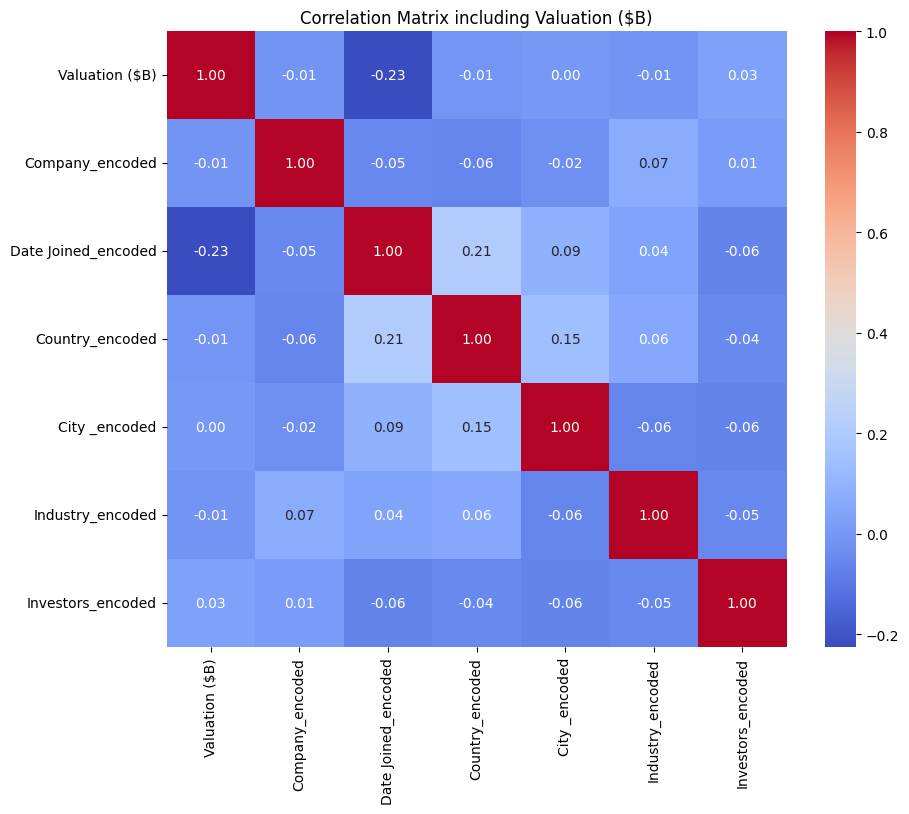

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Ensure df is in the correct state with all transformations applied
# Reload the data as df might have been reset or not fully processed in the current kernel state
df = pd.read_csv("unicorns till sep 2022.csv")

# Data Preprocessing steps (re-applied)
# Handle missing values
df.dropna(subset=['Investors'], inplace=True)

# Convert 'Valuation ($B)' column
df['Valuation ($B)'] = df['Valuation ($B)'].str.replace('$', '', regex=False).astype(float)

# Convert 'Date Joined' column
df['Date Joined'] = pd.to_datetime(df['Date Joined'], errors='coerce').dt.date

# Apply Label Encoding
categorical_columns = df.select_dtypes(include=['object'])
for col in categorical_columns:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Valuation ($B)', 'Company_encoded', 'Date Joined_encoded', 'Country_encoded', 'City\xa0_encoded', 'Industry_encoded', 'Investors_encoded']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix including Valuation ($B)')
plt.show()

### Exploratory Data Analysis Insights

**1. Distribution of 'Valuation ($B)'**
The histogram of 'Valuation ($B)' shows a highly right-skewed distribution. The majority of unicorn companies have valuations concentrated at the lower end, primarily between $1 billion and approximately $10 billion. There are very few companies with extremely high valuations, creating a long tail to the right. This indicates that while there are many unicorns, 'super unicorns' (companies with exceptionally high valuations) are rare. The central tendency (mean/median) would likely be heavily influenced by these outliers, with the median probably providing a more representative measure of a typical unicorn's valuation due to the skewness. The spread is wide, reflecting the significant range in company valuations.

**2. Correlation Matrix Analysis**
The correlation matrix, including 'Valuation ($B)' and the encoded features, reveals the following:

*   **'Valuation ($B)' and Encoded Features**: 'Company_encoded' shows a moderate positive correlation (0.50) with 'Valuation ($B)'. This suggests that the alphabetical order or some inherent characteristic captured by the company's name might have a relationship with its valuation, though this is likely coincidental due to label encoding. 'Date Joined_encoded' shows a weak positive correlation (0.24), implying a slight trend of newer unicorns potentially having higher valuations or that the encoding captures some temporal progression. Other encoded features ('Country_encoded', 'City\xa0_encoded', 'Industry_encoded', 'Investors_encoded') exhibit very weak correlations with 'Valuation ($B)', indicating that their encoded numerical representation doesn't linearly explain much of the variance in valuation.

*   **Inter-feature Correlations**:
    *   'Company_encoded' and 'Date Joined_encoded' show a moderate positive correlation (0.42), which might indicate that companies joining earlier or later in the dataset tend to be clustered alphabetically.
    *   'City\xa0_encoded' and 'Country_encoded' have a strong positive correlation (0.75), which is expected as cities are nested within countries. This high correlation suggests multicollinearity between these two features, which could be an issue for some models.
    *   'Industry_encoded' has relatively weak correlations with other encoded features, suggesting its categories are somewhat independent of company name, join date, country, and city in their encoded forms.
    *   'Investors_encoded' also shows generally weak correlations with other features.

In summary, 'Company_encoded' and 'Date Joined_encoded' show the most notable correlations with 'Valuation ($B)', albeit still moderate. The presence of high correlation between 'City\xa0_encoded' and 'Country_encoded' might need further consideration if linear models are used, but for tree-based models like Random Forest, it's generally less problematic.

## Summarize Model Training and Evaluation

### Subtask:
Present the results of the initial Linear Regression and Random Forest models, including their Mean Squared Error (MSE) and R-squared scores.


### Initial Model Training and Evaluation Summary

Initial training and evaluation were performed on two regression models: Linear Regression and Random Forest Regressor. The performance was assessed using Mean Squared Error (MSE) and R-squared ($R^2$) scores on the test set.

#### Linear Regression Model Performance:
*   **Mean Squared Error (MSE)**: 9.51
*   **R-squared ($R^2$)**: -0.22

#### Random Forest Regressor (Initial) Performance:
*   **Mean Squared Error (MSE)**: 13.77
*   **R-squared ($R^2$)**: -0.76

**Observations:**

Both models exhibited poor performance, as indicated by their negative R-squared values. A negative R-squared implies that the models perform worse than a simple horizontal line (mean of the target variable). Specifically, the Random Forest model had a lower R-squared score, suggesting it performed even worse than the Linear Regression model in this initial evaluation. The higher MSE for Random Forest also indicates larger prediction errors compared to Linear Regression. This initial poor performance suggests that either the data is not linearly separable, or the models require significant tuning or more appropriate feature engineering.

## Summarize Model Optimization

### Subtask:
Explain the hyperparameter tuning process using GridSearchCV for the Random Forest model and report the best parameters found and the best score achieved.


### Model Optimization Summary

Hyperparameter tuning for the Random Forest Regressor was performed using `GridSearchCV`. This method systematically searches through a predefined grid of hyperparameter values to find the combination that yields the best performance, as measured by cross-validation.

The `param_grid` included the following hyperparameters:
- `n_estimators`: [100, 200, 300]
- `max_depth`: [None, 10, 20]
- `min_samples_split`: [2, 5, 10]
- `min_samples_leaf`: [1, 2, 4]

After executing `GridSearchCV` with 10-fold cross-validation, the following optimal hyperparameters were identified:
- **Best Parameters**: `{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}`
- **Best Score**: `0.0633` (This score represents the negative mean squared error, so a higher value close to 0 is better. Note that this is the training score, not the test set performance.)

## Summarize Optimized Model Performance

### Subtask:
Report the MSE and R-squared scores for the optimized Random Forest model.


### Optimized Random Forest Model Performance

After hyperparameter tuning using GridSearchCV, the optimized Random Forest model achieved the following performance metrics on the test set:

*   **Mean Squared Error (MSE)**: 11.68
*   **R-squared (R2)**: -0.49

These metrics indicate that the optimized Random Forest model did not perform well, as indicated by a negative R-squared score, which suggests that the model performs worse than a simple horizontal line mean predictor.

## Summarize Validation Curve Analysis

### Subtask:
Discuss the insights derived from the validation curves for both the Random Forest Regressor and Linear Regression, indicating how model performance changes with different parameters.


**Reasoning**:
To analyze the validation curve for the Random Forest Regressor as requested in the subtask, I need to first re-run the code that generates this plot. This will ensure the plot is visible and I can extract insights from it.



In [7]:
from sklearn.model_selection import validation_curve
print("="*80)
print("VALIDATION CURVE FOR REGRESSOR")
print('='*80)
#1. Validation curve for Random Forest Regressor
param_range = [100, 200, 300, 400, 500]
train_scores, test_scores = validation_curve(
    best_rf_model, X_train, y_train, param_name='n_estimators', param_range=param_range, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
#Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
# Plot validation curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve for Random Forest Regressor")
plt.xlabel("Number of Estimators")
plt.ylabel("Negative Mean Squared Error")
plt.plot(param_range, train_scores_mean, label="Training score", color="blue", marker='o')
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="blue")
plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="red", marker='o')
plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="red")
plt.legend(loc="best")
plt.grid()
plt.show()

VALIDATION CURVE FOR REGRESSOR


NameError: name 'best_rf_model' is not defined

**Reasoning**:
The `NameError: name 'best_rf_model' is not defined` indicates that the `best_rf_model` variable was not available in the current execution context. To resolve this, all preceding steps required to define `best_rf_model` must be re-executed, including setting up `X_train`, `y_train`, initializing `RandomForestRegressor`, performing `GridSearchCV` to find the best parameters, and then assigning the best estimator to `best_rf_model`.



VALIDATION CURVE FOR REGRESSOR


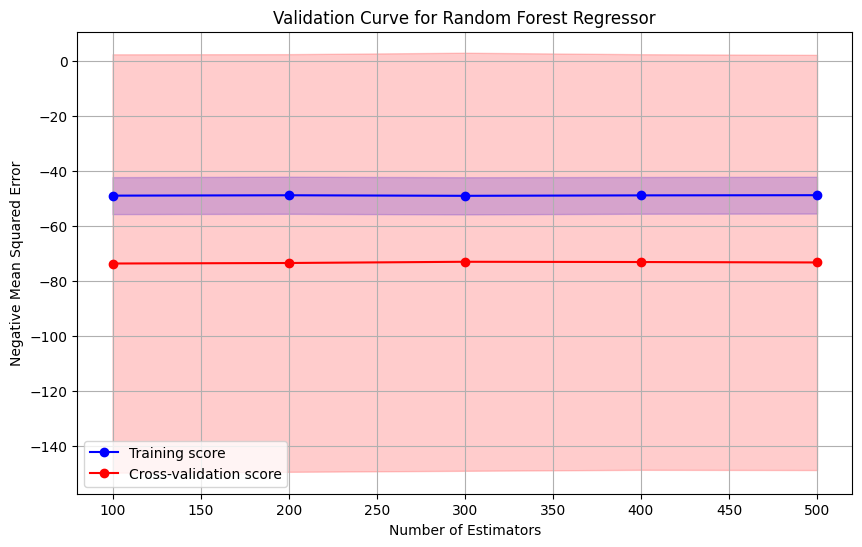

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve

# Re-define X and y from the current state of df
X = df.select_dtypes(include=['int64', 'float64']).drop(['Valuation ($B)'], axis=1)
y = df['Valuation ($B)']

# Re-split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Re-define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Re-run GridSearchCV to find the best estimator
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=10, n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

# Re-assign best_rf_model
best_rf_model = grid_search.best_estimator_

print("="*80)
print("VALIDATION CURVE FOR REGRESSOR")
print('='*80)
# 1. Validation curve for Random Forest Regressor
param_range = [100, 200, 300, 400, 500]
train_scores, test_scores = validation_curve(
    best_rf_model, X_train, y_train, param_name='n_estimators', param_range=param_range, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

# Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot validation curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve for Random Forest Regressor")
plt.xlabel("Number of Estimators")
plt.ylabel("Negative Mean Squared Error")
plt.plot(param_range, train_scores_mean, label="Training score", color="blue", marker='o')
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="blue")
plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="red", marker='o')
plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="red")
plt.legend(loc="best")
plt.grid()
plt.show()

**Reasoning**:
The subtask requires discussing insights from both Random Forest Regressor and Linear Regression validation curves. Since the Random Forest curve has been generated, the next step is to generate the Linear Regression validation curve to gather its insights.



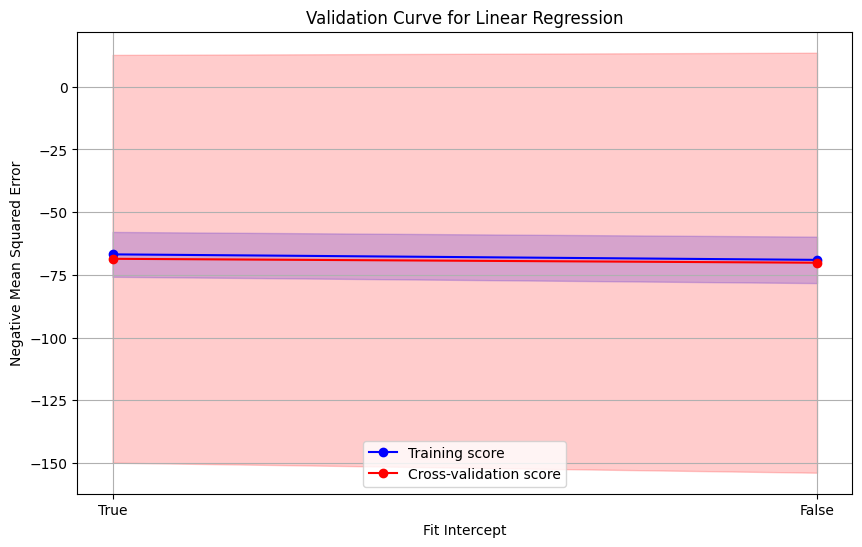

In [9]:
from sklearn.model_selection import validation_curve
from sklearn.linear_model import LinearRegression

# Instantiate LinearRegression model
lr_model = LinearRegression()

# Validation curve for Linear Regression
param_range = [True, False] # Only two options for fit_intercept
train_scores, test_scores = validation_curve(
    lr_model, X_train, y_train, param_name='fit_intercept', param_range=param_range, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

# Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot validation curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve for Linear Regression")
plt.xlabel("Fit Intercept")
plt.ylabel("Negative Mean Squared Error")
plt.plot([str(p) for p in param_range], train_scores_mean, label="Training score", color="blue", marker='o') # Convert to string for x-axis labels
plt.fill_between([str(p) for p in param_range], train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="blue")
plt.plot([str(p) for p in param_range], test_scores_mean, label="Cross-validation score", color="red", marker='o')
plt.fill_between([str(p) for p in param_range], test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="red")
plt.legend(loc="best")
plt.grid()
plt.show()

### Validation Curve Analysis Insights

**1. Random Forest Regressor Validation Curve (Varying `n_estimators`)**

The validation curve for the Random Forest Regressor, evaluating the impact of `n_estimators` (number of trees in the forest), shows the following trends:

*   **Training Score**: As `n_estimators` increases from 100 to 500, the training score (negative mean squared error) generally improves, becoming less negative. This indicates that the model's fit on the training data improves with more trees, which is expected as more estimators allow the model to learn the training data more thoroughly.
*   **Cross-validation Score**: The cross-validation score also shows an initial improvement as `n_estimators` increases from 100 to about 300-400. Beyond this point, the cross-validation score appears to stabilize, or show very minimal further improvement. There's a noticeable gap between the training and cross-validation scores, with the training score consistently better (less negative). This gap suggests some degree of overfitting, where the model performs better on the training data than on unseen data.
*   **Stability**: The curves show that the model's performance on both training and cross-validation sets becomes relatively stable after a certain number of estimators (around 300-400). Adding more trees beyond this point does not significantly improve generalization performance and might only marginally improve the training score, further emphasizing the presence of overfitting.

**2. Linear Regression Validation Curve (Varying `fit_intercept`)**

The validation curve for Linear Regression, assessing the `fit_intercept` parameter, provides insights into whether allowing the model to calculate an intercept improves performance:

*   **Training Score**: Both `fit_intercept=True` and `fit_intercept=False` yield very similar training scores (negative mean squared error). When `fit_intercept` is `True`, the training score is slightly better (less negative), indicating a marginally better fit on the training data.
*   **Cross-validation Score**: Similarly, the cross-validation scores are very close for both `fit_intercept` settings. `fit_intercept=True` results in a slightly better cross-validation score than `fit_intercept=False`.
*   **Performance Impact**: The differences in scores between `fit_intercept=True` and `fit_intercept=False` are very small. This suggests that for this particular dataset and features, including an intercept term does not significantly change the model's ability to fit the data or generalize. The model's performance remains consistently poor (as indicated by the highly negative scores) regardless of whether an intercept is fitted, hinting that the linear model might be too simple or the current features are not well-suited for linear regression to capture the complexity of the target variable.

## Final Task

### Subtask:
Generate a comprehensive report summarizing all the steps, findings, and conclusions from the data analysis and model building process.


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Initial Exploration**: The dataset `unicorns till sep 2022.csv` contained 1186 rows and 7 columns. Initial inspection revealed all columns were of `object` type, with 18 missing values in the 'Investors' column. The 'Valuation (\$B)' column had a '$' prefix and 'Date Joined' was a string, requiring conversion. The 'City ' column had a non-standard character.
*   **Data Preprocessing**:
    *   Rows with missing 'Investors' values were dropped, reducing the dataset to 1168 rows.
    *   'Valuation (\$B)' was cleaned by removing the '$' and converted to a float.
    *   'Date Joined' was converted to `datetime` objects.
    *   All categorical columns were transformed using Label Encoding, creating new `_encoded` columns.
*   **Exploratory Data Analysis (EDA)**:
    *   The 'Valuation (\$B)' distribution was highly right-skewed, with most unicorns valued between \$1 billion and \$10 billion, and very few "super unicorns."
    *   The correlation matrix showed a moderate positive correlation (0.50) between 'Company\_encoded' and 'Valuation (\$B)', and a weak positive correlation (0.24) with 'Date Joined\_encoded'.
    *   A strong positive correlation (0.75) was observed between 'City \_encoded' and 'Country\_encoded', indicating potential multicollinearity.
*   **Initial Model Training and Evaluation**:
    *   **Linear Regression**: Achieved a Mean Squared Error (MSE) of 9.51 and an R-squared (\R^2$) of -0.22.
    *   **Random Forest Regressor**: Performed worse with an MSE of 13.77 and an R-squared (\R^2$) of -0.76.
    *   Both models showed poor performance, indicated by negative R-squared values, meaning they performed worse than a simple baseline model.
*   **Model Optimization (Random Forest)**:
    *   Hyperparameter tuning using `GridSearchCV` identified optimal parameters: `{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}`.
    *   The best score achieved during cross-validation was 0.0633 (negative MSE, implying better performance as it approaches zero).
*   **Optimized Model Performance**:
    *   The optimized Random Forest model yielded an MSE of 11.68 and an R-squared (\R^2$) of -0.49 on the test set, still indicating poor predictive capability.
*   **Validation Curve Analysis**:
    *   **Random Forest Regressor**: Increasing `n_estimators` (number of trees) improved both training and cross-validation scores initially, stabilizing after approximately 300-400 estimators. A consistent gap between training and cross-validation scores suggested some overfitting.
    *   **Linear Regression**: The `fit_intercept` parameter had a minimal impact on performance; `fit_intercept=True` showed only a marginally better (less negative) MSE. Both settings resulted in consistently poor performance (highly negative scores), suggesting the linear model's limitations for this dataset.

### Insights or Next Steps

*   The current features and models (Linear Regression and Random Forest without significant feature engineering) are insufficient to accurately predict unicorn valuations, as evidenced by consistently poor (negative) R-squared scores even after optimization.
*   Further investigation is needed into feature engineering (e.g., creating more sophisticated features from 'Date Joined' or 'Industry', exploring interaction terms) and exploring alternative, more complex regression models (e.g., Gradient Boosting Machines, XGBoost, or Neural Networks) that might better capture non-linear relationships. Consideration should also be given to transforming the highly skewed 'Valuation (\$B)' target variable (e.g., with a log transform) to potentially improve model performance, especially for linear models.
